# 05 — Fine-tuned DistilBERT

**Why this model?** Unlike the frozen sentence transformer (notebook 04), fine-tuning adapts all layers of the model to our specific education policy domain. This should help with the remaining confusion between `political_environment`, `what_matters_ed`, and `policy_practice_research` — categories that share general language but may have domain-specific patterns a generic model misses.

**How it works:** DistilBERT is a smaller, faster version of BERT (40% fewer parameters). We add a classification head on top and fine-tune the entire model end-to-end on our 6 categories. With only 942 training rows, we use small-dataset techniques to avoid overfitting: low learning rate, few epochs, weight decay, and early stopping.

**Risk:** 942 rows is borderline for fine-tuning a transformer. If this doesn't beat the frozen sentence transformer (0.765), the bottleneck is data size, not model capacity.

**Steps:**
1. Tokenise text with DistilBERT tokeniser
2. Fine-tune DistilBERT with early stopping, low learning rate, weight decay
3. Evaluate: macro F1, top-2 accuracy, per-class breakdown, calibration
4. Compare to baseline (0.675) and sentence transformer (0.765)
5. Save model

**Input:** `data/modelling/train.csv`, `data/modelling/val.csv`

**Benchmarks to beat:** TF-IDF baseline 0.675, Sentence Transformer 0.765

# 0. Imports

In [1]:
import pandas as pd
import numpy as np
import json
from pathlib import Path

import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

%matplotlib inline

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [2]:
DATA_DIR = Path("../data/modelling")
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# 1. Load data

In [3]:
train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")

# Label encode: DistilBERT needs integer labels, not strings
label_names = sorted(train_df["target"].unique())
label2id = {name: i for i, name in enumerate(label_names)}
id2label = {i: name for name, i in label2id.items()}

print(f"Train: {train_df.shape[0]} rows")
print(f"Val:   {val_df.shape[0]} rows")
print(f"\nLabel mapping:")
for name, idx in label2id.items():
    print(f"  {idx}: {name}")

Train: 942 rows
Val:   167 rows

Label mapping:
  0: edtech
  1: four_nations
  2: policy_practice_research
  3: political_environment_key_organisations
  4: teacher_rrd
  5: what_matters_ed


# 2. Tokenise

In [4]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")


class NewsletterDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.encodings = tokenizer(
            texts, truncation=True, padding=True, max_length=max_length, return_tensors="pt"
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item["labels"] = self.labels[idx]
        return item


train_labels = train_df["target"].map(label2id).tolist()
val_labels = val_df["target"].map(label2id).tolist()

train_dataset = NewsletterDataset(train_df["text_clean"].tolist(), train_labels, tokenizer)
val_dataset = NewsletterDataset(val_df["text_clean"].tolist(), val_labels, tokenizer)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset:   {len(val_dataset)} samples")
print(f"Token length:  {train_dataset.encodings['input_ids'].shape[1]}")

Train dataset: 942 samples
Val dataset:   167 samples
Token length:  128


# 3. Fine-tune DistilBERT

Small dataset techniques:
- **Low learning rate** (2e-5) — prevents catastrophic forgetting of pretrained knowledge
- **Few epochs** (5 max) — less chance to overfit
- **Weight decay** (0.01) — regularisation
- **Early stopping** — stop if val loss doesn't improve for 2 epochs
- **Warmup** — gradually increase learning rate at the start

In [5]:
# Compute class weights for imbalanced data
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight("balanced", classes=np.array(label_names), y=train_df["target"])
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)
print(f"Class weights: {dict(zip(label_names, class_weights.round(2)))}")

Class weights: {'edtech': np.float64(1.05), 'four_nations': np.float64(1.29), 'policy_practice_research': np.float64(1.15), 'political_environment_key_organisations': np.float64(0.77), 'teacher_rrd': np.float64(0.95), 'what_matters_ed': np.float64(0.94)}


In [6]:
# Hyperparameters
BATCH_SIZE = 4
LEARNING_RATE = 2e-5
EPOCHS = 5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
PATIENCE = 2  # early stopping patience
ACCUMULATION_STEPS = 4   

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

# Model
model_bert = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
)
model_bert.to(device)

# Optimiser with weight decay
optimizer = torch.optim.AdamW(model_bert.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Scheduler with warmup
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Loss with class weights
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Total steps: {total_steps}")
print(f"Warmup steps: {warmup_steps}")
print(f"Batches per epoch: {len(train_loader)}")

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total steps: 295
Warmup steps: 29
Batches per epoch: 59


In [7]:
# Training loop with early stopping
best_val_loss = float("inf")
patience_counter = 0
train_losses = []
val_losses = []

for epoch in range(EPOCHS):
    # Train
    model_bert.train()
    epoch_train_loss = 0
    optimizer.zero_grad()

    for step, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_bert(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        loss = loss_fn(outputs.logits, batch["labels"]) / ACCUMULATION_STEPS

        loss.backward()
        epoch_train_loss += loss.item() * ACCUMULATION_STEPS

        if (step + 1) % ACCUMULATION_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model_bert.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

    avg_train_loss = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validate
    model_bert.eval()
    epoch_val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model_bert(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
            loss = loss_fn(outputs.logits, batch["labels"])
            epoch_val_loss += loss.item()

    avg_val_loss = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} — Train loss: {avg_train_loss:.4f}, Val loss: {avg_val_loss:.4f}")

    # Early stopping
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        best_state = {k: v.clone() for k, v in model_bert.state_dict().items()}
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"\nEarly stopping at epoch {epoch+1} (no improvement for {PATIENCE} epochs)")
            break

# Restore best model
model_bert.load_state_dict(best_state)
print(f"\nBest val loss: {best_val_loss:.4f}")

Epoch 1/5 — Train loss: 1.7119, Val loss: 1.4532
Epoch 2/5 — Train loss: 1.1214, Val loss: 0.9155
Epoch 3/5 — Train loss: 0.6986, Val loss: 0.8001
Epoch 4/5 — Train loss: 0.5398, Val loss: 0.7648
Epoch 5/5 — Train loss: 0.4519, Val loss: 0.7636

Best val loss: 0.7636


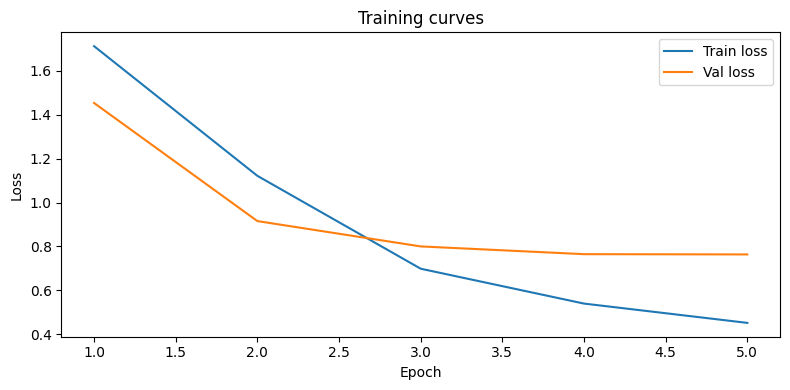

In [8]:
# Plot training curves
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(train_losses)+1), train_losses, label="Train loss")
ax.plot(range(1, len(val_losses)+1), val_losses, label="Val loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training curves")
ax.legend()
plt.tight_layout()
plt.show()

### Training curves

Both losses drop — the model is learning. Val loss flattens after epoch 3 (0.80 → 0.76 → 0.76) while train loss keeps falling (0.70 → 0.45). The growing gap from epoch 3 onwards shows the model is starting to overfit — learning training-specific patterns rather than generalising. 5 epochs was the right choice; more would widen the gap further without improving val loss.


# 4. Evaluate

In [9]:
# Get predictions and probabilities
model_bert.eval()
all_logits = []

with torch.no_grad():
    for batch in val_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model_bert(input_ids=batch["input_ids"], attention_mask=batch["attention_mask"])
        all_logits.append(outputs.logits.cpu())

logits = torch.cat(all_logits, dim=0)
y_proba = torch.softmax(logits, dim=1).numpy()
y_pred = np.argmax(y_proba, axis=1)

# Convert back to label names
y_pred_names = [id2label[i] for i in y_pred]
y_val_names = val_df["target"].tolist()

macro_f1 = f1_score(y_val_names, y_pred_names, average="macro")
print(f"Macro F1: {macro_f1:.3f}\n")
print(classification_report(y_val_names, y_pred_names))

Macro F1: 0.750

                                         precision    recall  f1-score   support

                                 edtech       0.86      0.96      0.91        26
                           four_nations       0.95      0.95      0.95        22
               policy_practice_research       0.72      0.54      0.62        24
political_environment_key_organisations       0.61      0.47      0.53        36
                            teacher_rrd       0.70      0.90      0.79        29
                        what_matters_ed       0.67      0.73      0.70        30

                               accuracy                           0.74       167
                              macro avg       0.75      0.76      0.75       167
                           weighted avg       0.74      0.74      0.73       167



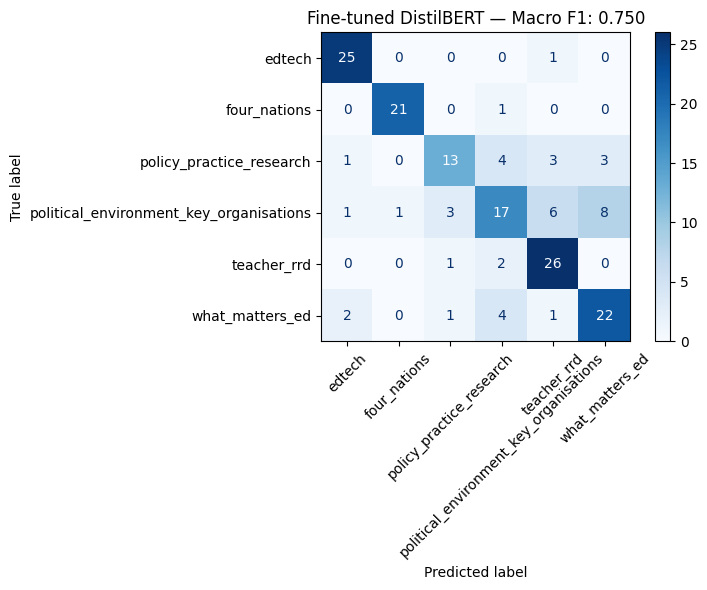

In [10]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_val_names, y_pred_names, ax=ax, xticks_rotation=45, cmap="Blues"
)
ax.set_title(f"Fine-tuned DistilBERT — Macro F1: {macro_f1:.3f}")
plt.tight_layout()
plt.show()

In [11]:
# Top-k and per-class top-2 accuracy
classes = np.array(label_names)

for k in [1, 2]:
    top_k_preds = np.argsort(y_proba, axis=1)[:, -k:]
    top_k_correct = [
        label2id[true] in top_k
        for true, top_k in zip(y_val_names, top_k_preds)
    ]
    print(f"Top-{k} accuracy: {np.mean(top_k_correct):.3f}")

print("\nPer-class top-2 accuracy:\n")
for cls in label_names:
    mask = np.array(y_val_names) == cls
    top2_preds = np.argsort(y_proba[mask], axis=1)[:, -2:]
    cls_idx = label2id[cls]
    hit_rate = np.mean([cls_idx in row for row in top2_preds])
    print(f"  {cls:45s} {hit_rate:.0%}  ({mask.sum()} samples)")

Top-1 accuracy: 0.743
Top-2 accuracy: 0.886

Per-class top-2 accuracy:

  edtech                                        96%  (26 samples)
  four_nations                                  95%  (22 samples)
  policy_practice_research                      67%  (24 samples)
  political_environment_key_organisations       89%  (36 samples)
  teacher_rrd                                   93%  (29 samples)
  what_matters_ed                               90%  (30 samples)


In [12]:
# Missed predictions
print("--- MISSED: true label not in top 2 ---\n")
for i in range(len(y_val_names)):
    true_label = y_val_names[i]
    top2_idx = np.argsort(y_proba[i])[-2:][::-1]
    top2 = [(id2label[j], y_proba[i][j]) for j in top2_idx]

    if true_label not in [c for c, _ in top2]:
        print(f"True: {true_label}")
        print(f"  1. {top2[0][0]} ({top2[0][1]:.2f})  2. {top2[1][0]} ({top2[1][1]:.2f})")
        print(f"  Text: {val_df.iloc[i]['text_clean'][:150]}")
        print()

--- MISSED: true label not in top 2 ---

True: policy_practice_research
  1. political_environment_key_organisations (0.38)  2. teacher_rrd (0.25)
  Text: Education Endowment Foundation - New local partnerships launched to help disadvantaged pupils Up to 223 schools will benefit from eight new local part

True: teacher_rrd
  1. political_environment_key_organisations (0.68)  2. what_matters_ed (0.11)
  Text: Ofsted: what scrapping single-word inspection grades will mean for teachers Rachel Harding, Research Fellow in Social Sciences, Nottingham Trent Unive

True: four_nations
  1. political_environment_key_organisations (0.72)  2. what_matters_ed (0.08)
  Text: Government devolution bill - 'Devolution Revolution' forges ahead with more powers for Mayors Raft of new powers will enable Mayors to drive economic 

True: policy_practice_research
  1. political_environment_key_organisations (0.40)  2. what_matters_ed (0.19)
  Text: One innovation is £500m for the regions and their mayors to 

In [14]:
# False positives: model predicted this class but it was actually something else
for cls in label_names:
    print(f"\n--- False positives for {cls} ---\n")
    for i in range(len(y_val_names)):
        if y_pred_names[i] == cls and y_val_names[i] != cls:
            print(f"  Predicted: {cls} ({y_proba[i][label2id[cls]]:.2f})")
            print(f"  Actual:    {y_val_names[i]}")
            print(f"  Text:      {val_df.iloc[i]['text_clean'][:150]}")
            print()


--- False positives for edtech ---

  Predicted: edtech (0.88)
  Actual:    policy_practice_research
  Text:      NEW INQUIRY: Lords Communications and Digital Committee - Large language models How this tech is likely to evolve in the next few years and whether re

  Predicted: edtech (0.42)
  Actual:    what_matters_ed
  Text:      Becky Allen's Substack - Curriculum is a localist model of a distributed mind Argues that knowledge stored in the brain as "patterns of activation dis

  Predicted: edtech (0.59)
  Actual:    what_matters_ed
  Text:      Analysis reveals extent of SEND stealth funding cuts Samantha Booth Special Needs Jungle research reveals top-up funding has been stagnant since 2018 

  Predicted: edtech (0.91)
  Actual:    political_environment_key_organisations
  Text:      DfE - Young people to benefit from creative education boost New package announced to support young people to access high-quality arts education and en


--- False positives for four_nations ---

  P

### Interpretation

**Macro F1: 0.750** — matches sentence transformer LogReg but doesn't beat the sentence transformer + metadata (0.765). DistilBERT excels on distinctive classes (`four_nations` 95%, `edtech` 96%) but is weaker on the overlapping categories (`policy_practice_research` 54%, `political_environment` 47%).

**Top-2: 88.6%** — below sentence transformer (91.6%). DistilBERT is more confident on easy classes but less reliable on ambiguous ones. `policy_practice_research` at 67% top-2 (vs 83% with sentence transformer) is the clear weak spot.

**19 missed articles (vs 14 with sentence transformer).** Same `political_environment` ↔ `policy_practice_research` ↔ `what_matters_ed` triangle — these categories overlap in meaning (who/what type/what topic), which is a labelling schema problem, not a model problem. DistilBERT is also more overconfident on wrong predictions (0.70-0.91 confidence on incorrect classes), making it less safe for the curator than the sentence transformer's more cautious probabilities.

**Conclusion:** fine-tuning didn't beat frozen embeddings + metadata. The bottleneck is category overlap, not model capacity. Sentence transformer + metadata (0.765, 91.6% top-2) remains the best model.

### False positives analysis
`political_environment` false positives are mostly reasonable — the model and curator just disagree on whether to categorise by source or topic. `teacher_rrd` false positives are more concerning — the model triggers on any mention of "teacher" or "school" even when the article isn't about teacher recruitment/retention. This suggests DistilBERT is relying on keyword-like patterns despite being a semantic model, reinforcing that fine-tuning on 942 rows wasn't enough to learn deeper distinctions.

## 4b. Calibration check

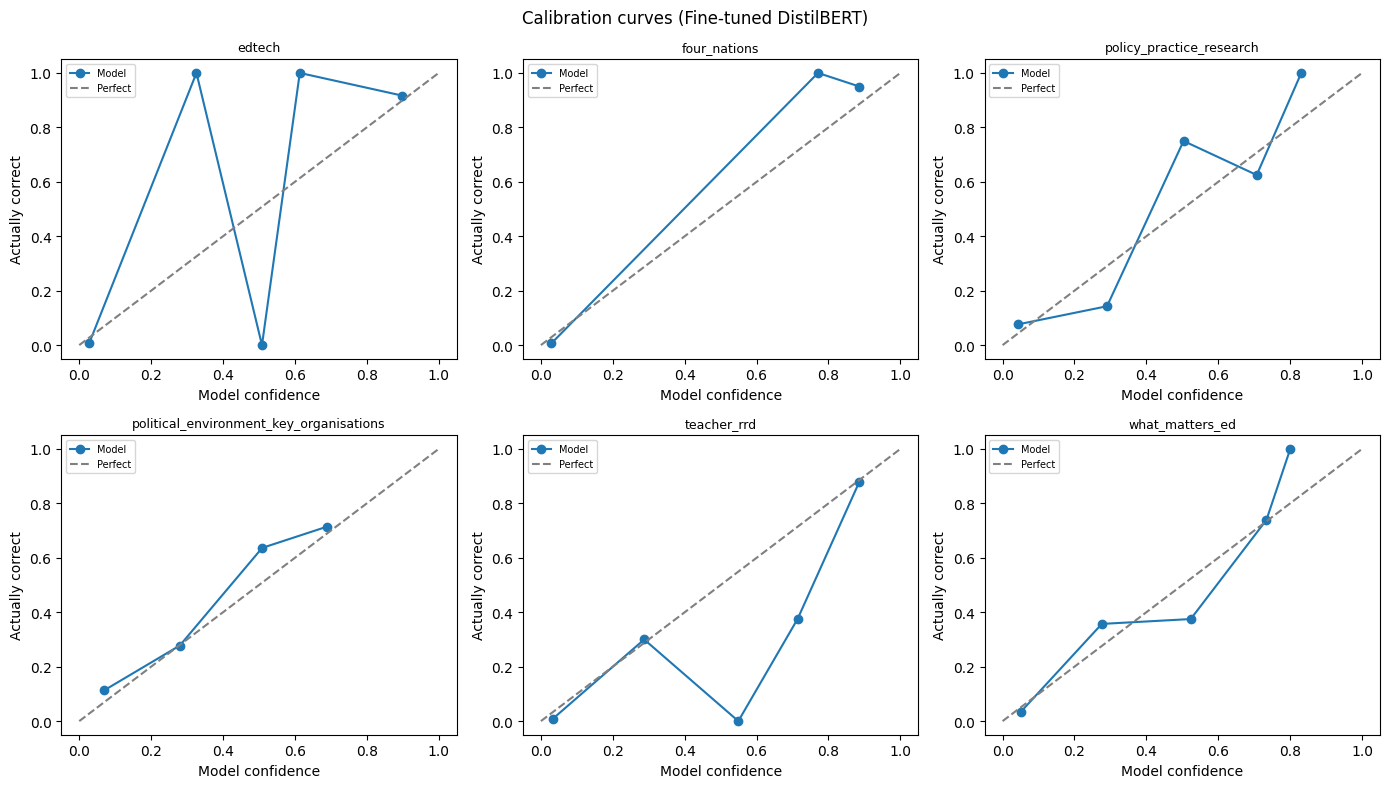

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, cls in enumerate(label_names):
    mask = (np.array(y_val_names) == cls).astype(int)
    prob_true, prob_pred = calibration_curve(
        mask,
        y_proba[:, i],
        n_bins=5,
        strategy="uniform",
    )

    axes[i].plot(prob_pred, prob_true, marker="o", label="Model")
    axes[i].plot([0, 1], [0, 1], "--", color="grey", label="Perfect")
    axes[i].set_title(cls, fontsize=9)
    axes[i].set_xlabel("Model confidence")
    axes[i].set_ylabel("Actually correct")
    axes[i].legend(fontsize=7)

plt.suptitle("Calibration curves (Fine-tuned DistilBERT)")
plt.tight_layout()
plt.show()


### Calibration

Poorly calibrated — overconfident on several classes, erratic curves. Fine-tuning on 942 rows made the model learn high-confidence patterns that don't generalise. The sentence transformer's calibration was significantly better and safer for the curator.

# 5. Compare to previous models

In [17]:
# Compare all three models
# Baseline (notebook 03): text-only TF-IDF + LogReg
# Sentence Transformer (notebook 04): all-MiniLM-L6-v2 + LogReg + metadata
# DistilBERT (this notebook): fine-tuned end-to-end

top2_preds = np.argsort(y_proba, axis=1)[:, -2:]
top2_correct = [
    label2id[true] in top2
    for true, top2 in zip(y_val_names, top2_preds)
]
distilbert_top2 = np.mean(top2_correct)

print(f"{'Model':<30} {'Macro F1':>10} {'Top-2':>10}")
print(f"{'-'*50}")
print(f"{'TF-IDF + LogReg':<30} {'0.675':>10} {'0.874':>10}")
print(f"{'Sentence Transformer':<30} {'0.765':>10} {'0.916':>10}")
print(f"{'Fine-tuned DistilBERT':<30} {macro_f1:>10.3f} {distilbert_top2:>10.3f}")


Model                            Macro F1      Top-2
--------------------------------------------------
TF-IDF + LogReg                     0.675      0.874
Sentence Transformer                0.765      0.916
Fine-tuned DistilBERT               0.750      0.886


# 6. Save model

In [18]:
save_path = MODEL_DIR / "distilbert_finetuned"
model_bert.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)

print(f"Saved to {save_path}/")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to ../models/distilbert_finetuned/


# Summary & Conclusions

## Results

| Model | Macro F1 | Top-2 accuracy |
|-------|----------|----------------|
| TF-IDF + LogReg (baseline) | 0.675 | 87.4% |
| Sentence Transformer + LogReg + metadata | **0.765** | **91.6%** |
| Fine-tuned DistilBERT | 0.750 | 88.6% |

## Key findings

**Fine-tuning didn't beat frozen embeddings.** DistilBERT (0.750) matches the sentence transformer LogReg (0.750) but falls short of the sentence transformer + metadata (0.765). With only 942 training rows, fine-tuning doesn't learn enough domain-specific patterns to justify the added complexity and training time.

**DistilBERT is better on distinctive classes but worse on ambiguous ones.** `four_nations` (95% recall) and `edtech` (96%) are the strongest across all models, but `policy_practice_research` (54% recall, 67% top-2) is the worst we've seen. The model is more decisive but less balanced.

**Overconfident and poorly calibrated.** Unlike the sentence transformer (underconfident, safe), DistilBERT produces high-confidence wrong predictions (0.70–0.91 on incorrect classes). Erratic calibration curves confirm this. For a curator tool where confidence scores guide attention, unreliable confidence is a serious drawback.

**False positive analysis revealed keyword-like behaviour.** Despite being a semantic model, DistilBERT triggers on surface-level patterns — any mention of "teacher" or "school" pulls towards `teacher_rrd` regardless of the article's actual focus. Fine-tuning on 942 rows wasn't enough to learn deeper distinctions.

**The category overlap triangle persists across all models.** `political_environment` ↔ `policy_practice_research` ↔ `what_matters_ed` accounts for most errors. These categories describe overlapping dimensions (who/what type/what topic) — a labelling schema issue, not a model issue.

**No text+metadata comparison** — DistilBERT takes raw text tokens as input, so metadata can't be easily concatenated the same way. Not justified given the model already underperforms the sentence transformer.

## Conclusion

Sentence transformer + LogReg + metadata (0.765, 91.6% top-2) remains the best model. Fine-tuning added training time (~30 mins on CPU), worse calibration, and no accuracy improvement. The bottleneck is category overlap in the labelling schema, not model capacity.

## Saved artefacts

- `models/distilbert_finetuned/` — fine-tuned model + tokeniser

**Next:** `06_claude_api.ipynb` — zero-shot and few-shot Claude API classifiers
